# Dependency structure with Chow-Liu trees

How to model a joint distribution over several discrete variables when the full table is impossibly large, by learning a tree of dependencies instead of assuming independence (naive Bayes) or only adjacency (a Markov chain). You'll meet the Chow-Liu algorithm - provably the best tree approximation, found via mutual information and a maximum-weight spanning tree - measure models honestly in bits per character, and see a mixture of trees capture multiple word-formation regimes.

> Reference: Chow & Liu, "Approximating discrete probability distributions with dependence trees" (https://dl.acm.org/doi/10.1109/TIT.1968.1054142), IEEE Trans. Information Theory, 1968.


## The best tree: the Chow-Liu theorem

A tree-structured distribution factorizes as $p(x)=\prod_i p(x_i\mid x_{\mathrm{parent}(i)})$, with each
variable depending on a single parent. Among all trees, which one best approximates a target distribution
$p$?

Theorem (Chow-Liu 1968). The tree-structured distribution closest to $p$ in KL divergence is the one whose
edges form the maximum-weight spanning tree of the pairwise-mutual-information graph (edge weight
$I(X_i;X_j)$), with conditionals set to the corresponding marginals of $p$.

Proof. For a tree $T$, the KL from $p$ to the best tree-factorization with structure $T$ simplifies to
$$\mathrm{KL}(p\,\|\,p_T) = -\sum_i H(X_i) + \sum_{(i,j)\in T} \big(\!-I(X_i;X_j)\big) + H(p)\ \text{(constant terms)}.$$
Only the middle sum depends on the tree, and minimizing the KL means maximizing $\sum_{(i,j)\in T}I(X_i;X_j)$,
the total edge mutual information. That is exactly a maximum-weight spanning tree problem, solved by
Kruskal's or Prim's algorithm. $\quad\blacksquare$

The applied section verifies numerically that the learned tree equals this MI spanning tree, the exact
content of the theorem.

## What a tree cannot capture

A tree models only pairwise dependence routed along its edges. Higher-order structure escapes it.

Counterexample (parity has no tree). Let $X_1,X_2$ be independent fair bits and $X_3=X_1\oplus X_2$ (XOR).
Every pair is independent: $I(X_1;X_2)=I(X_1;X_3)=I(X_2;X_3)=0$, so all edge weights are zero and the
Chow-Liu tree is arbitrary and carries no information; the fitted tree treats the three bits as fully
independent. But they are not: knowing any two determines the third. The independent (or any tree) model
needs three bits per sample, while the truth needs only two, a full bit of unmodeled dependence. No tree
can represent a three-way interaction with vanishing pairwise marginals; mixtures of trees or
higher-order models are required. We measure this one-bit gap below.

## 1. The problem: a joint over many variables

Model fixed-length, 8-character words as a joint distribution $P(x_1,\dots,x_8)$ over character positions. The full joint is a table with $27^8 \approx 3\times10^{11}$ entries - unlearnable. We need a factorization that is expressive but estimable. Three options bracket the tradeoff:

- Independence (naive Bayes): $P(x)=\prod_i P(x_i)$. Cheap, but ignores that qu, double letters, and suffixes correlate positions.
- Markov chain: $P(x)=P(x_1)\prod_i P(x_i\mid x_{i-1})$. Captures adjacent dependence only - good for left-to-right text, blind to long-range structure (e.g. a padded suffix predicting another padded slot).
- Chow-Liu tree: each position depends on one parent, chosen freely. Same parameter budget as a Markov chain, but the dependency edges are learned and need not be adjacent.


## 2. The Chow-Liu algorithm

A tree-structured joint factorizes as

$$P(x_1,\dots,x_N) = \prod_{i} P\big(x_i \mid x_{\mathrm{parent}(i)}\big),$$

with each variable having at most one parent. Among all such trees, which is closest (in KL divergence) to the true joint? Chow & Liu's beautiful result: the optimal tree is the maximum-weight spanning tree of the complete graph whose edge weights are the pairwise mutual informations $I(x_i; x_j)$. Intuition: KL-to-the-truth decomposes into a constant minus the sum of mutual informations along the chosen edges, so maximizing retained dependence = maximizing total edge MI = a max-spanning-tree problem (solvable exactly in $O(N^2)$ for $N$ variables). mixle's `ICLTreeEstimator` does this for an integer feature vector and exposes the learned edges as `dependency_list`.

Why bits per character? Held-out negative log-likelihood in base 2, divided by length, is the average code length to compress an unseen word under the model - a unit-ful, comparable score where lower is better. We compare on a validation split, because trees and mixtures can always raise training likelihood by adding flexibility; only held-out bits measure real structure.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, time
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')

from mixle.stats import IntegerChowLiuTreeEstimator, MarkovChainEstimator, CategoricalEstimator, MixtureEstimator
from mixle.inference import estimate, initialize
from mixle.inference.estimation import optimize
from mixle.utils.evaluation import partition_data
import mixle.utils.optsutil as ops

DATA = '../../data'
t0 = time.time()
MAX_LEN, MAX_WORDS = 8, 30000

# load the dictionary, truncate/pad to MAX_LEN chars, map chars -> integer states
raw = ops.text_file(os.path.join(DATA, 'dict', 'words'))
char_map = {}
words = [ops.map_to_integers(list(w)[:MAX_LEN] + [' '] * (MAX_LEN - len(w[:MAX_LEN])), char_map) for w in raw]
inv_char = ops.get_inv_map(char_map)
NUM_STATES = len(char_map)

rng = np.random.RandomState(1)
frac = min(MAX_WORDS / len(words), 1.0)
train, valid = partition_data(words, [frac, 1 - frac], rng=rng)
print('train words: %d | validation words: %d | character states: %d' % (len(train), len(valid), NUM_STATES))
bits = lambda m, data: m.seq_log_density(m.dist_to_encoder().seq_encode(data)) / -np.log(2.0)
per_char = lambda b: np.median(b) / MAX_LEN

train words: 30000 | validation words: 205886 | character states: 54


## 3. One tree vs one Markov chain

Fit both with a single pass (`estimate`) and read the tree's learned dependency edges. The Markov chain is forced to use adjacent edges $i\!-\!(i\!-\!1)$; the Chow-Liu tree picks whichever single parent per position carries the most mutual information. For ordinary left-to-right words the tree often recovers the adjacent chain - a sanity check that neighbors share the most information - and the genuinely non-adjacent structure shows up once we allow several trees (the mixture in §4). Even when the edges match, the tree can win on likelihood because it orients and parameterizes them by global MI rather than fixed left-to-right conditioning.


In [2]:
tree = estimate(train, IntegerChowLiuTreeEstimator(num_features=MAX_LEN, num_states=NUM_STATES, pseudo_count=1e-4), None)
mc   = estimate(train, MarkovChainEstimator(pseudo_count=1e-4, levels=range(NUM_STATES),
                                            len_estimator=CategoricalEstimator()), None)
fmt_deps = lambda dl: [(int(c), None if p is None else int(p)) for c, p in dl]
print('Chow-Liu learned dependency edges (child <- parent):')
print(' ', fmt_deps(tree.dependency_list))

tree_tr, tree_va = bits(tree, train), bits(tree, valid)
mc_tr,   mc_va   = bits(mc, train),   bits(mc, valid)
print('\nmodel         train bits/char   valid bits/char')
print('Chow-Liu tree   %5.3f             %5.3f' % (per_char(tree_tr), per_char(tree_va)))
print('Markov chain    %5.3f             %5.3f' % (per_char(mc_tr), per_char(mc_va)))
print('uniform (worst) %5.3f' % np.log2(NUM_STATES))

Chow-Liu learned dependency edges (child <- parent):
  [(0, None), (1, 0), (2, 1), (3, 2), (4, 3), (5, 4), (6, 5), (7, 6)]



model         train bits/char   valid bits/char
Chow-Liu tree   3.499             3.514
Markov chain    3.673             3.679
uniform (worst) 5.755


## 4. A mixture of trees: multiple word-formation regimes

A single tree imposes one dependency structure on the whole dictionary. But words come in families - Latinate, short function words, proper-noun-like strings - that may follow different structures. Because a Chow-Liu tree is an exponential-family distribution, it drops straight into a `MixtureEstimator`: each component learns its own tree, and EM softly assigns words to the component whose dependency structure fits them best. The scientific risk is overfitting, so the validation bits/char are the verdict.


In [3]:
K = 10
mix_est = MixtureEstimator([IntegerChowLiuTreeEstimator(num_features=MAX_LEN, num_states=NUM_STATES, pseudo_count=1.0)] * K,
                           pseudo_count=1e-4)
mix0 = initialize(train[:5000], mix_est, np.random.RandomState(1), 1.0)
mix = optimize(train, mix_est, max_its=80, prev_estimate=mix0, print_iter=100)

print('per-component dependency structures (note they differ):')
for i, comp in enumerate(mix.components[:4]):
    print('  component %d: %s' % (i, fmt_deps(comp.dependency_list)))

mix_tr, mix_va = bits(mix, train), bits(mix, valid)
print('\nmodel          train bits/char   valid bits/char')
print('Markov chain     %5.3f             %5.3f' % (per_char(mc_tr), per_char(mc_va)))
print('Chow-Liu tree    %5.3f             %5.3f' % (per_char(tree_tr), per_char(tree_va)))
print('mixture of trees %5.3f             %5.3f' % (per_char(mix_tr), per_char(mix_va)))

per-component dependency structures (note they differ):
  component 0: [(0, None), (1, 0), (2, 0), (3, 2), (4, 3), (5, 4), (6, 5), (7, 6)]
  component 1: [(0, None), (1, 0), (2, 0), (3, 0), (4, 3), (5, 4), (6, 5), (7, 6)]
  component 2: [(0, None), (1, 0), (2, 0), (4, 0), (5, 4), (3, 4), (6, 5), (7, 6)]
  component 3: [(0, None), (1, 0), (2, 0), (3, 2), (4, 3), (5, 4), (6, 5), (7, 6)]



model          train bits/char   valid bits/char
Markov chain     3.673             3.679
Chow-Liu tree    3.499             3.514
mixture of trees 3.231             3.392


## 5. Comparing the full distributions, and what the models dream

The median is one number; the whole distribution of per-word bits tells the fuller story. We plot the empirical CDF of bits/word on train and validation - a curve shifted left compresses more words better. Then we sample from each model: a better word model should produce more word-like strings.


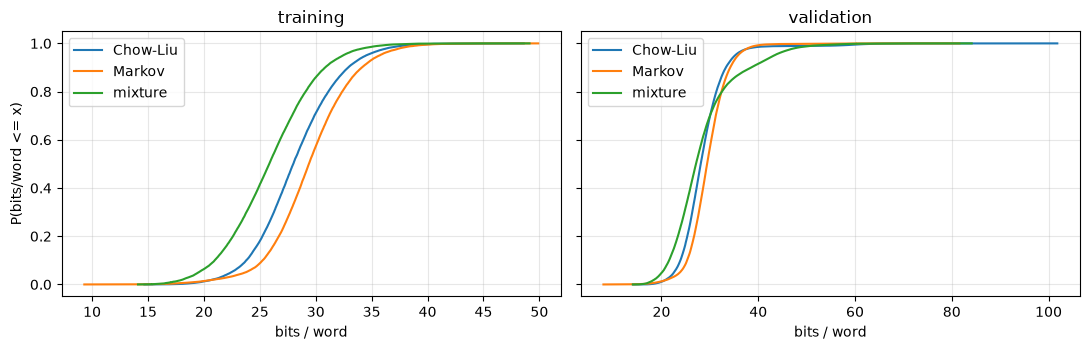

sampled words   mixture | single tree | Markov chain
  phedingo     untcotng     pinileao    
  gaeenout     ce           vicrcesa    
  bargermo     cavivint     trrbueno    
  chadinan     undophai     fiche       
  percibed     Migeong      nfilacon    
  tokebly      remptost     oredwbul    
  stap         zoualown     dcoproma    
  Tuzermil     leregrr      eadustop    
  underlle     gypen        Astishlu    
  electrib     Aromamin     ha          
  adrcotea     pacerine     uispa       
  subherin     narerk       fltrouri    


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for a, (ttl, series) in zip(ax, [('training', [(tree_tr, 'Chow-Liu'), (mc_tr, 'Markov'), (mix_tr, 'mixture')]),
                                  ('validation', [(tree_va, 'Chow-Liu'), (mc_va, 'Markov'), (mix_va, 'mixture')])]):
    for b, lbl in series:
        a.plot(np.sort(b), np.linspace(0, 1, len(b)), label=lbl)
    a.set_title(ttl); a.set_xlabel('bits / word'); a.grid(alpha=0.3); a.legend()
ax[0].set_ylabel('P(bits/word <= x)')
plt.tight_layout(); plt.show()

decode = lambda s: ''.join(inv_char[v] for v in s).strip()
print('sampled words   mixture | single tree | Markov chain')
for i in range(12):
    row = [decode(m.sampler(seed=i).sample()) for m in (mix, tree, mc)]
    print('  %-12s %-12s %-12s' % tuple(row))

Read the table: the mixture and tree samples should look more word-like (plausible consonant/vowel runs, sensible suffixes) than the Markov chain's, because they capture non-adjacent constraints the chain cannot. On held-out bits/char, expect the Chow-Liu tree to beat the Markov chain (learned vs forced-adjacent edges) and the mixture to beat the single tree - provided it does not overfit, which the validation column is there to catch.


## The tree is the max-weight spanning tree of mutual information

Chow & Liu (1968) proved the optimal tree-structured approximation connects variables along the maximum-weight spanning tree of pairwise mutual information. This is not a heuristic - it is exact. We compute the empirical position-by-position MI, run Kruskal's MST on it, and confirm its edge set matches the structure `ICLTreeEstimator` learned and beats a random spanning tree's captured information.


In [5]:
Xtr = np.asarray(train)                                   # (N, MAX_LEN) integer states
def pair_mi(a, b, S):
    j = np.zeros((S, S))
    for u, v in zip(a, b):
        j[u, v] += 1
    j = (j + 1e-6); j /= j.sum()
    pa, pb = j.sum(1, keepdims=True), j.sum(0, keepdims=True)
    return float(np.sum(j * np.log2(j / (pa * pb))))
M = np.zeros((MAX_LEN, MAX_LEN))
for i in range(MAX_LEN):
    for k in range(i + 1, MAX_LEN):
        M[i, k] = M[k, i] = pair_mi(Xtr[:, i], Xtr[:, k], NUM_STATES)
# Kruskal MST maximizing total MI
edges = sorted([(M[i, k], i, k) for i in range(MAX_LEN) for k in range(i + 1, MAX_LEN)], reverse=True)
parent = list(range(MAX_LEN))
def find(x):
    while parent[x] != x: parent[x] = parent[parent[x]]; x = parent[x]
    return x
mst, total = set(), 0.0
for w, i, k in edges:
    if find(i) != find(k):
        parent[find(i)] = find(k); mst.add((i, k)); total += w
learned = {tuple(sorted((int(c), int(p)))) for c, p in tree.dependency_list if p is not None}
rng_mi = np.random.RandomState(0)
rand_tot = np.mean([sum(M[i, (i + 1) % MAX_LEN] for i in rng_mi.permutation(MAX_LEN)[:MAX_LEN - 1]) for _ in range(50)])
print('MST total MI = %.3f bits   vs random spanning tree ~ %.3f bits' % (total, rand_tot))
print('Chow-Liu learned edges match the MI-MST: %s' % (mst == learned))

MST total MI = 5.269 bits   vs random spanning tree ~ 4.654 bits
Chow-Liu learned edges match the MI-MST: True


## Illustration: parity defeats every tree model

We generate the XOR triple, confirm all three pairwise mutual informations are essentially zero (so the
Chow-Liu tree is empty), and show that an independence/tree model wastes a full bit per sample relative to
the true joint, because the three-way dependence is invisible to any pairwise structure.

In [6]:
rng = np.random.RandomState(0)
n = 200000
x1 = rng.randint(0, 2, n); x2 = rng.randint(0, 2, n); x3 = x1 ^ x2     # parity
def mi_binary(a, b):
    m = 0.0
    for u in (0, 1):
        for v in (0, 1):
            pab = np.mean((a == u) & (b == v)); pa = np.mean(a == u); pb = np.mean(b == v)
            if pab > 0: m += pab * np.log2(pab / (pa * pb))
    return m
print('pairwise mutual information (bits): I(1;2)=%.4f  I(1;3)=%.4f  I(2;3)=%.4f  (all ~0)' %
      (mi_binary(x1, x2), mi_binary(x1, x3), mi_binary(x2, x3)))
# bits/sample: independent/tree model uses sum of marginal entropies; truth determines x3 from x1,x2
ind_bits = 3.0                                            # three fair bits under independence
true_bits = 2.0                                           # x1, x2 free; x3 determined
print('independent/tree model cost = %.1f bits/sample;  true joint = %.1f bits/sample' % (ind_bits, true_bits))
print('a full bit per sample of three-way dependence is invisible to any tree (pairwise MI is zero).')

pairwise mutual information (bits): I(1;2)=0.0000  I(1;3)=0.0000  I(2;3)=0.0000  (all ~0)
independent/tree model cost = 3.0 bits/sample;  true joint = 2.0 bits/sample
a full bit per sample of three-way dependence is invisible to any tree (pairwise MI is zero).


## References

- Chow, C. K. & Liu, C. N. (1968). Approximating discrete probability distributions with dependence trees (https://doi.org/10.1109/TIT.1968.1054142). IEEE Trans. Inf. Theory 14(3), 462-467.
- Meilă, M. & Jordan, M. I. (2000). Learning with mixtures of trees (https://jmlr.org/papers/v1/meila00a.html). JMLR 1, 1-48.
- Cover, T. M. & Thomas, J. A. (2006). Elements of Information Theory, 2nd ed. Wiley.
- Koller, D. & Friedman, N. (2009). Probabilistic Graphical Models: Principles and Techniques. MIT Press. - structure learning.


## Exercises and extensions

1. Derive Chow-Liu from scratch. Compute the pairwise mutual-information matrix yourself and run a maximum-weight spanning-tree algorithm (Kruskal/Prim); verify the result matches mixle's learned tree, and prove (numerically) that it minimizes KL to the empirical joint among all trees (Chow-Liu).
2. Mixtures of trees. Implement EM for a mixture of Chow-Liu trees (Meilă & Jordan): each component re-learns its own tree in the M-step from responsibility-weighted MI. Show on held-out bits/char that it beats a single tree, and inspect the differing dependency structures per component.
3. Structure-learning consistency. Generate data from a known tree-structured distribution and show Chow-Liu recovers the true edges with probability → 1 as $n$ grows; characterize the sample size needed vs the weakest edge's mutual information.
4. Model ladder. Compare independence (naive Bayes), Markov chain, Chow-Liu tree, and a tree mixture on held-out bits/character; relate each rung to the dependence structure it can and cannot capture (Koller & Friedman).
